In [ ]:

# IMPORT LIBRARIES
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
#  GENERATE SYNTHETIC DATASET

# Function to generate one synthetic image
def generate_image(img_size=64):
    
    # Create empty black image
    img = np.zeros((img_size, img_size))
    
    # Random object size
    size = np.random.randint(8, 16)
    
    # Random position
    x = np.random.randint(0, img_size - size)
    y = np.random.randint(0, img_size - size)
    
    # Randomly choose shape
    shape_type = np.random.choice(["square", "circle"])
    
    if shape_type == "square":
        # Draw square
        img[x:x+size, y:y+size] = 1
        
    elif shape_type == "circle":
        # Draw circle
        cx, cy = x + size//2, y + size//2
        for i in range(img_size):
            for j in range(img_size):
                if (i - cx)**2 + (j - cy)**2 <= (size//2)**2:
                    img[i, j] = 1
    
    # Bounding box: (x, y, width, height)
    box = (x, y, size, size)
    
    return img, box


# Creating dataset
train_images = []
train_boxes = []

for _ in range(50):   # 50 training samples
    img, box = generate_image()
    train_images.append(img)
    train_boxes.append(box)

# Convert to numpy arrays
train_images = np.array(train_images)
train_boxes = np.array(train_boxes)

# Print dataset info
print("Images shape:", train_images.shape)
print("Boxes shape:", train_boxes.shape)

Images shape: (50, 64, 64)
Boxes shape: (50, 4)


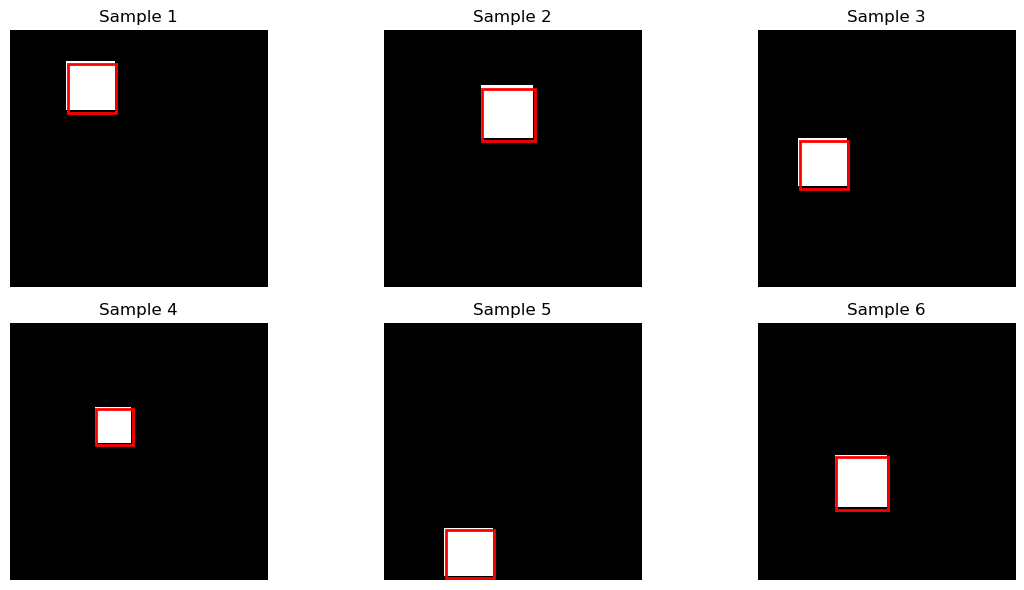

In [ ]:

# VISUALIZE SAMPLES


# Number of samples to display
num_samples = 6

plt.figure(figsize=(12, 6))

for i in range(num_samples):
    
    # Select image and its bounding box
    img = train_images[i]
    x, y, w, h = train_boxes[i]
    
    # Plot image
    plt.subplot(2, 3, i+1)
    plt.imshow(img, cmap='gray')
    
    # Draw bounding box
    plt.gca().add_patch(
        plt.Rectangle((y, x), w, h, edgecolor='red', fill=False, linewidth=2)
    )
    
    plt.title(f"Sample {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# CELL 4: REGION PROPOSAL (SLIDING WINDOW)


def get_regions(image, window_size=14, stride=7):
    """
    Generates region proposals using sliding window
    
    Parameters:
    - image: input image (64x64)
    - window_size: size of each region (e.g., 14x14)
    - stride: step size for sliding
    
    Returns:
    - regions: list of image patches
    - boxes: list of bounding boxes (x, y, w, h)
    """
    
    h, w = image.shape
    
    regions = []
    boxes = []
    
    # Slide window across image
    for i in range(0, h - window_size, stride):
        for j in range(0, w - window_size, stride):
            
            # Extract patch
            patch = image[i:i+window_size, j:j+window_size]
            
            # Save region
            regions.append(patch)
            
            # Save bounding box (x, y, width, height)
            boxes.append((i, j, window_size, window_size))
    
    return regions, boxes


# Test on one image
sample_img = train_images[0]

regions, region_boxes = get_regions(sample_img)

print("Total regions generated:", len(regions))
print("Example region shape:", regions[0].shape)

Total regions generated: 64
Example region shape: (14, 14)


In [ ]:
# CELL 5: IoU + REGION LABELING
def compute_iou(box1, box2):
    """
    Computes Intersection over Union (IoU)
    
    box format: (x, y, w, h)
    """
    
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    
    # Convert to (x1,y1,x2,y2)
    x1_max, y1_max = x1 + w1, y1 + h1
    x2_max, y2_max = x2 + w2, y2 + h2
    
    # Intersection
    xi1 = max(x1, x2)
    yi1 = max(y1, y2)
    xi2 = min(x1_max, x2_max)
    yi2 = min(y1_max, y2_max)
    
    inter_w = max(0, xi2 - xi1)
    inter_h = max(0, yi2 - yi1)
    intersection = inter_w * inter_h
    
    # Union
    area1 = w1 * h1
    area2 = w2 * h2
    union = area1 + area2 - intersection
    
    return intersection / union if union != 0 else 0


def label_regions(region_boxes, gt_box, threshold=0.3):
    """
    Assign labels to each region
    
    If IoU >= threshold → object (1)
    Else → background (0)
    """
    
    labels = []
    
    for box in region_boxes:
        iou = compute_iou(box, gt_box)
        
        if iou >= threshold:
            labels.append(1)  # object
        else:
            labels.append(0)  # background
    
    return np.array(labels)


# Test labeling on one image
gt_box = train_boxes[0]

labels = label_regions(region_boxes, gt_box)

print("Total regions:", len(labels))
print("Positive regions (object):", np.sum(labels))
print("Negative regions (background):", len(labels) - np.sum(labels))

Total regions: 64
Positive regions (object): 2
Negative regions (background): 62


In [ ]:
# ============================================
# CNN (CONVOLUTION LAYER)
# ============================================

class Conv:
    def __init__(self, num_filters):
        """
        Initialize convolution layer
        num_filters: number of filters (output channels)
        """
        # Random filters (3x3)
        self.filters = np.random.randn(num_filters, 3, 3) / 9

    def forward(self, image):
        """
        Forward pass
        
        Input: single region (H x W)
        Output: feature map (H-2 x W-2 x num_filters)
        """
        self.last_input = image
        
        h, w = image.shape
        self.output = np.zeros((h-2, w-2, len(self.filters)))
        
        # Apply each filter
        for f in range(len(self.filters)):
            for i in range(h-2):
                for j in range(w-2):
                    patch = image[i:i+3, j:j+3]
                    self.output[i, j, f] = np.sum(patch * self.filters[f])
        
        return self.output

    def backward(self, dL_dout, lr):
        """
        Backward pass (update filters)
        """
        dL_dfilters = np.zeros(self.filters.shape)

        for f in range(len(self.filters)):
            for i in range(dL_dout.shape[0]):
                for j in range(dL_dout.shape[1]):
                    patch = self.last_input[i:i+3, j:j+3]
                    dL_dfilters[f] += dL_dout[i, j, f] * patch

        # Update filters
        self.filters -= lr * dL_dfilters


# Initialize conv layer
conv = Conv(num_filters=4)

# Test forward pass on one region
test_region = regions[0]
conv_out = conv.forward(test_region)

print("Input shape:", test_region.shape)
print("Output shape:", conv_out.shape)

Input shape: (14, 14)
Output shape: (12, 12, 4)


In [ ]:
# CELL 7: ReLU ACTIVATION + FLATTEN

def relu(x):
    """
    ReLU activation function
    Converts negative values to 0
    """
    return np.maximum(0, x)


def relu_deriv(x):
    """
    Derivative of ReLU (for backprop)
    """
    return (x > 0).astype(float)


def flatten(x):
    """
    Convert 3D feature map into 1D vector
    (needed for classifier input)
    """
    return x.reshape(-1)


# Test on one region
out = conv.forward(regions[0])
out_relu = relu(out)
flat = flatten(out_relu)

print("After ReLU shape:", out_relu.shape)
print("Flattened shape:", flat.shape)

After ReLU shape: (12, 12, 4)
Flattened shape: (576,)


In [ ]:
# REGION CLASSIFIER (LOGISTIC REGRESSION)

class RegionClassifier:
    def __init__(self, input_size):
        """
        Initialize classifier
        
        input_size: size of flattened feature vector
        """
        self.weights = np.random.randn(input_size) / input_size
        self.bias = 0

    def forward(self, x):
        """
        Forward pass
        
        x: flattened feature vector
        """
        self.last_input = x
        return np.dot(x, self.weights) + self.bias

    def backward(self, dL_dout, lr):
        """
        Backpropagation
        
        dL_dout: gradient of loss
        lr: learning rate
        """
        # Gradient w.r.t weights
        dL_dw = self.last_input * dL_dout
        
        # Update weights
        self.weights -= lr * dL_dw
        self.bias -= lr * dL_dout
        
        # Return gradient to previous layer
        return self.weights * dL_dout


# Initialize classifier (we'll define size dynamically)
classifier = None


# Test classifier
sample_flat = flat  # from previous cell

if classifier is None:
    classifier = RegionClassifier(len(sample_flat))

score = classifier.forward(sample_flat)

print("Classifier output (raw score):", score)

Classifier output (raw score): 0.0


In [ ]:
# SIGMOID + LOSS FUNCTION

def sigmoid(x):
    """
    Converts raw score to probability (0 to 1)
    """
    x = np.clip(x, -50, 50)  # avoid overflow
    return 1 / (1 + np.exp(-x))


def loss_fn(pred, target):
    """
    Binary Cross Entropy Loss
    
    pred: predicted probability
    target: true label (0 or 1)
    """
    pred = np.clip(pred, 1e-7, 1 - 1e-7)  # avoid log(0)
    return -(target * np.log(pred) + (1 - target) * np.log(1 - pred))


def loss_deriv(pred, target):
    """
    Derivative of loss (sigmoid + BCE combined)
    """
    return pred - target


# Test on one sample
test_pred = sigmoid(score)
test_label = 1  # assume object

loss = loss_fn(test_pred, test_label)

print("Predicted probability:", test_pred)
print("Loss:", loss)

Predicted probability: 0.5
Loss: 0.6931471805599453


In [ ]:
# RCNN TRAIN STEP

def train_step(image, gt_box, lr=0.001):
    """
    Performs one training step on a single image
    
    image: input image
    gt_box: ground truth bounding box
    lr: learning rate
    """
    global classifier
    
    # 1. Generate regions
    regions, region_boxes = get_regions(image)
    
    # 2. Label regions using IoU
    labels = label_regions(region_boxes, gt_box)
    
    total_loss = 0
    
    # 3. Loop over each region
    for region, label in zip(regions, labels):
        
        # ---------- FORWARD ----------
        
        # CNN
        out = conv.forward(region)
        out_relu = relu(out)
        
        # Flatten
        flat = flatten(out_relu)
        
        # Initialize classifier if needed
        if classifier is None:
            classifier = RegionClassifier(len(flat))
        
        # Classifier + sigmoid
        score = classifier.forward(flat)
        pred = sigmoid(score)
        
        # Loss
        loss = loss_fn(pred, label)
        total_loss += loss
        
        
        # BackWord
        
        # Gradient from loss
        grad = loss_deriv(pred, label)
        
        # Backprop through classifier
        grad_cls = classifier.backward(grad, lr)
        
        # Reshape gradient back to feature map
        grad_cls = grad_cls.reshape(out_relu.shape)
        
        # Apply ReLU derivative
        grad_conv = grad_cls * relu_deriv(out)
        
        # Backprop through conv
        conv.backward(grad_conv, lr)
    
    return total_loss / len(regions)


# Test one training step
loss = train_step(train_images[0], train_boxes[0])

print("Loss after one train step:", loss)

Loss after one train step: 0.6863306050861158


In [ ]:
# TRAINING LOOP (BEST MODEL FIX ONLY)

epochs = 3

# Track best model
best_loss = float('inf')
best_conv_filters = None
best_classifier_weights = None
best_classifier_bias = None

for epoch in range(epochs):
    
    total_loss = 0
    
    # Shuffle data (important for learning)
    indices = np.random.permutation(len(train_images))
    
    for count, i in enumerate(indices):
        
        # SAME learning rate as before (unchanged)
        loss = train_step(train_images[i], train_boxes[i])
        total_loss += loss
        
        if count % 10 == 0:
            print(f"Epoch {epoch+1} | Step {count} | Loss: {loss:.4f}")
        
        if np.isnan(loss):
            print("Loss became NaN — stopping training")
            break
    
    avg_loss = total_loss / len(train_images)
    
    print(f"\nEpoch {epoch+1} Completed | Avg Loss: {avg_loss:.4f}\n")
    
    # ✅ Save best model (THIS is the only addition)
    if avg_loss < best_loss:
        best_loss = avg_loss
        best_conv_filters = conv.filters.copy()
        best_classifier_weights = classifier.weights.copy()
        best_classifier_bias = classifier.bias


# ✅ Restore best model after training
conv.filters = best_conv_filters
classifier.weights = best_classifier_weights
classifier.bias = best_classifier_bias

print("Best model restored with loss:", best_loss)

Epoch 1 | Step 0 | Loss: 0.6718
Epoch 1 | Step 10 | Loss: 0.5526
Epoch 1 | Step 20 | Loss: 0.4729
Epoch 1 | Step 30 | Loss: 0.4086
Epoch 1 | Step 40 | Loss: 0.3599

Epoch 1 Completed | Avg Loss: 0.4630

Epoch 2 | Step 0 | Loss: 0.3197
Epoch 2 | Step 10 | Loss: 0.2881
Epoch 2 | Step 20 | Loss: 0.2693
Epoch 2 | Step 30 | Loss: 0.2515
Epoch 2 | Step 40 | Loss: 0.2090

Epoch 2 Completed | Avg Loss: 0.2528

Epoch 3 | Step 0 | Loss: 0.2017
Epoch 3 | Step 10 | Loss: 0.1856
Epoch 3 | Step 20 | Loss: 0.1718
Epoch 3 | Step 30 | Loss: 0.1644
Epoch 3 | Step 40 | Loss: 0.1359

Epoch 3 Completed | Avg Loss: 0.1662

Best model restored with loss: 0.16624192509762767


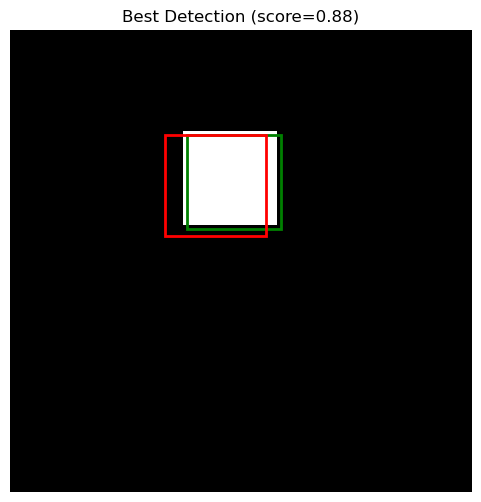

Best detection score: 0.8822954556705318


In [ ]:
# FINAL PREDICTION (BEST BOX ONLY)

def predict_best(image):
    """
    Returns the single best detected region
    """
    regions, boxes = get_regions(image)
    
    best_box = None
    best_score = -1
    
    for region, box in zip(regions, boxes):
        
        # Forward pass through RCNN
        out = conv.forward(region)
        out = relu(out)
        flat = flatten(out)
        
        prob = sigmoid(classifier.forward(flat))
        
        # Keep best scoring box
        if prob > best_score:
            best_score = prob
            best_box = box
    
    return best_box, best_score


# =========================
# TEST ON ONE IMAGE
# =========================

test_img = train_images[2]
gt_box = train_boxes[2]

best_box, score = predict_best(test_img)


# VISUALIZATION

plt.figure(figsize=(6,6))
plt.imshow(test_img, cmap='gray')

# Ground Truth (GREEN)
x, y, w, h = gt_box
plt.gca().add_patch(
    plt.Rectangle((y, x), w, h, edgecolor='green', fill=False, linewidth=2)
)

# Best Prediction (RED)
x, y, w, h = best_box
plt.gca().add_patch(
    plt.Rectangle((y, x), w, h, edgecolor='red', fill=False, linewidth=2)
)

plt.title(f"Best Detection (score={score:.2f})")
plt.axis('off')
plt.show()


# Print result
print("Best detection score:", score)